In [1]:
using GraphMakie, Graphs, NetworkLayout, CairoMakie
using GraphTransportation
using LinearAlgebra
using SparseArrays
include("src/utils.jl")

using Plots
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

[ Info: Precompiling GraphTransportation [0afaa0e9-cc38-4a4d-9239-d0953829ee9e] (cache misses: include_dependency fsize change (2), wrong source (4))


false

In [2]:
N=16
Q = Array(Tridiagonal(ones(7), zeros(8), ones(7)))
Q[1, 8] = 1
Q[8, 1] = 1
Q = hcat(Q, zeros(8))
Q = vcat(Q, zeros(9)')
Q[9,2] = Q[2,9] = Q[9,4] = Q[4,9] = Q[9,6] = Q[6,9] = Q[9,8] = Q[8,9] = 1

for (idx, row) in enumerate(eachrow(Q))
    z = sum(row)
    Q[idx, :] /= z
end

π = steady_state_from_adjacency(Q)
μ = zeros(9)
ν = zeros(9)
ρ = zeros(9)
μ[3] = 1/π[3]
ν[7] = 1/π[7]
ρ[5] = 1/π[5]
M = stack((μ, ν, ρ))

γ, d = BBD(Q, μ, ν, N, verbose=false, tol=1e-6);


◐ Progress:     Time: 0:00:19
   Difference in norm between iterations: 125.92885827978753
4m                       Current iteration: 2

In [3]:
function logmap(Q, ν, μ; N=16, tol=1e-6)
    curve, _ = BBD(Q, ν, μ, N, tol=tol, progress=false)
    return curve.vector.m[1,:,:]
end

function direction(Q, M, weights, μ; N=16, tol=1e-6)
    tangent_vector = zeros(size(Q))
    p = size(M, 2)
    for i=1:p
        tangent_vector = tangent_vector + weights[i] * logmap(Q, μ, M[:,i], N=N)
    end
    return -1 * tangent_vector
end

function metric_tensor(ρ, mean=geomean)
    N = size(ρ, 1)
    g = zeros(N,N)
    for i in 1:N
        for j in i+1:N
            g[i, j] = mean(ρ[i], ρ[j])
            g[j, i] = mean(ρ[i], ρ[j])
        end
    end
    return g
end

gradient_step(Q, μ, h, M, weights; N=16) = μ + h * graph_divergence(Q, metric_tensor(μ) .* direction(Q, M, weights, μ, N=N))'

gradient_step (generic function with 1 method)

In [4]:
function visualize_grid_barycenter(Q, measures;
                                 layout_alg=Spring(),
                                 node_size=15,
                                 colormap=:viridis,
                                 edge_width=1.0,
                                 edge_color=:gray80,
                                 filename=nothing,
                                 fixed_positions=nothing,
                                 colorbar=true,
                                 )
    M, V = size(measures)
    fig = Figure(size = (400*M, 400))
    g = SimpleDiGraph(Q)
    for i = 0:M-1
        v = measures[i+1,:]
        ax = Axis(fig[1, 2*i + 1], aspect=DataAspect())
        hidedecorations!(ax)
        hidespines!(ax)

        # Compute layout or use fixed positions
        positions = isnothing(fixed_positions) ?
            NetworkLayout.layout(layout_alg, g) :
            fixed_positions

        # Normalize node values for coloring
        vmin, vmax = extrema(v)
        normalized_v = (v .- vmin) ./ (vmax - vmin + eps())

        # Plot the graph
        graphplot!(ax, g,
                   layout=positions,
                   node_size=node_size,
                   node_color=v,
                   edge_width=edge_width,
                   edge_color=edge_color,
                   node_attr=(; colormap=colormap, colorrange=(vmin, vmax)))

        # Add colorbar if requested
        if colorbar
            Colorbar(fig[1, 2*i], limits=(vmin, vmax), colormap=colormap, label="Node Weight")
        end
    end

    if !isnothing(filename)
        save(filename, fig)
    end

    return fig
	
end

visualize_grid_barycenter (generic function with 1 method)

◐ Progress:     Time: 0:00:00
   Difference in norm between iterations: 2.890575892605869e-6
◐ Progress:     Time: 0:00:00ration: 122
   Difference in norm between iterations: 1.6076847478920554e-6
◐ Progress:     Time: 0:00:00ration: 129
   Difference in norm between iterations: 3.952349358456736e-6
◐ Progress:     Time: 0:00:00ration: 101
   Difference in norm between iterations: 3.007923293174012e-6
◐ Progress:     Time: 0:00:00ration: 116
   Difference in norm between iterations: 3.949655208793576e-6
◐ Progress:     Time: 0:00:00ration: 101
   Difference in norm between iterations: 2.6270637195313565e-6
◐ Progress:     Time: 0:00:00                      |  ETA: 0:00:52
   Difference in norm between iterations: 2.4029502846817342e-6
◐ Progress:     Time: 0:00:00ration: 108
   Difference in norm between iterations: 2.9522524832265802e-6
◐ Progress:     Time: 0:00:00ration: 117
   Difference in norm between iterations: 2.558439971367859e-6
◐ Progress:     Time: 0:00:00                

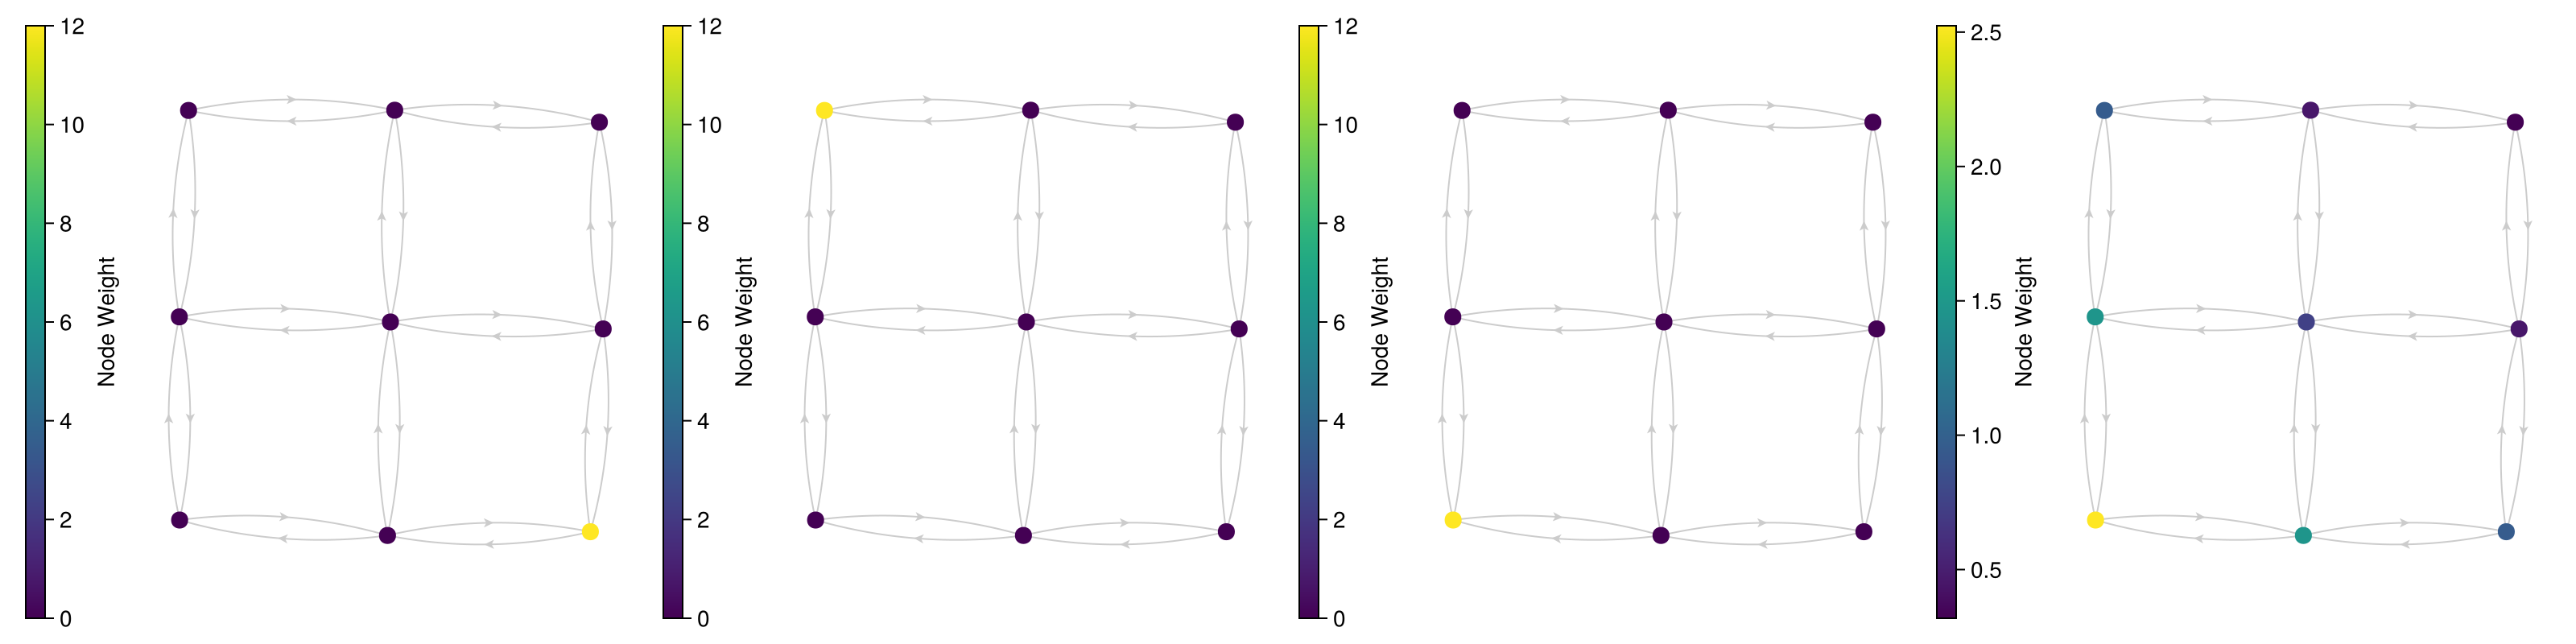

In [12]:
coords = ones(3) / 3
ρ_old = ones(9)
ρ_next = ones(9)
n_steps = 100
norm_diffs = zeros(n_steps)
@showprogress for i=1:n_steps
    ρ_next = gradient_step(Q, ρ_old, 0.05, M, coords, N=8)[:,1]
    norm_diffs[i] = norm(ρ_next - ρ_old)
    ρ_old = ρ_next
end

measures = hcat(M, ρ_next)
visualize_grid_barycenter(Q, measures')

◓ Progress:     Time: 0:00:00
   Difference in norm between iterations: 1.1694628921111793e-6
◐ Progress:     Time: 0:00:00ration: 227
   Difference in norm between iterations: 9.994130736699118e-6
Progress: 100%|█████████████████████████████████████████| Time: 0:00:53


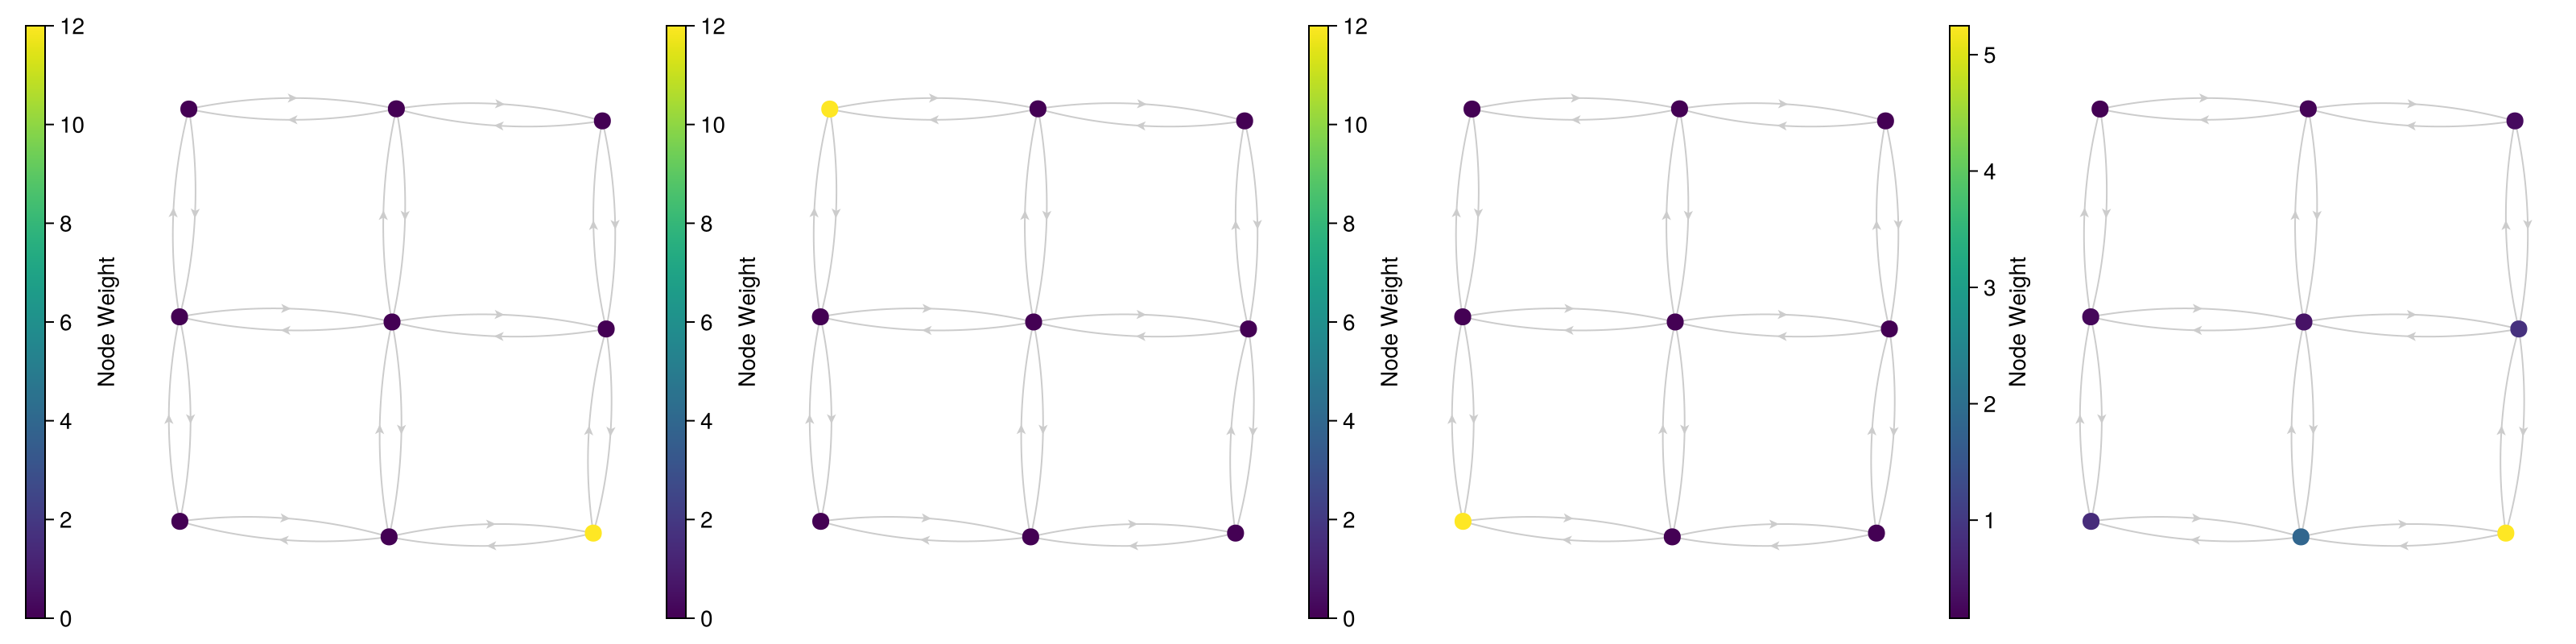

In [13]:
coords = [0.75; 0.125; 0.125]
ρ_old = ones(9)
ρ_next = ones(9)
n_steps = 100
norm_diffs = zeros(n_steps)
@showprogress for i=1:n_steps
    ρ_next = gradient_step(Q, ρ_old, 0.05, M, coords, N=8)[:,1]
    norm_diffs[i] = norm(ρ_next - ρ_old)
    ρ_old = ρ_next
end

measures = hcat(M, ρ_next)
visualize_grid_barycenter(Q, measures')

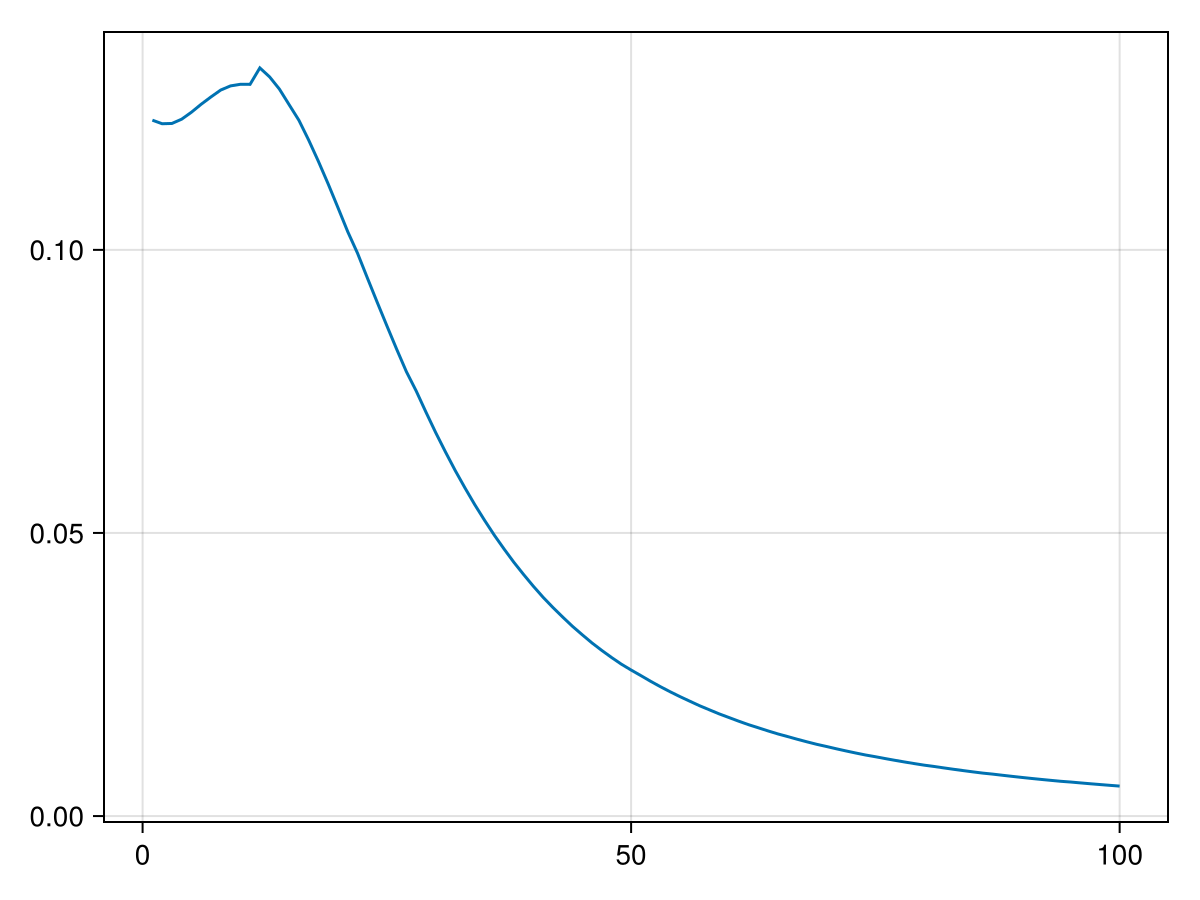

In [18]:
f = Figure()
ax = f[1,1]
lines(norm_diffs)